# Custom MT Button-Press + Push Results Notebook

Notebook για το custom multi-task experiment:

```text
button-press-v3 + push-v3
```

Το training script εκπαιδεύει ένα κοινό PPO policy με observation:

```text
Meta-World observation + one-hot task ID
button-press-v3 -> [1, 0]
push-v3         -> [0, 1]
```

Το notebook υποστηρίζει δύο ειδών evaluation results:

1. **Custom wrapper evaluation** από `evaluate_button_push_custom_mt.py`
2. **Individual MT1 env evaluation** από `evaluate_custom_mt_button_push_individual.py`
.

## Load result files

Default folders:

```text
button_push_eval_results/
individual_env_eval_results/
```

In [1]:
from pathlib import Path
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore

# 1. Results from evaluate_button_push_custom_mt.py
CUSTOM_EVAL_DIR = Path('button_push_eval_results')
CUSTOM_SUMMARY_PATH = CUSTOM_EVAL_DIR / 'button_push_eval_summary.csv'
CUSTOM_RAW_PATH = CUSTOM_EVAL_DIR / 'button_push_eval_raw_episodes.csv'
CUSTOM_PIVOT_PATH = CUSTOM_EVAL_DIR / 'button_push_success_rate_pivot.csv'

# 2. Results from evaluate_custom_mt_button_push_individual.py
INDIV_EVAL_DIR = Path('individual_env_eval_results')
INDIV_FINAL_PATH = INDIV_EVAL_DIR / 'individual_env_final_summary.csv'
INDIV_BY_SEED_PATH = INDIV_EVAL_DIR / 'individual_env_summary_by_seed.csv'
INDIV_RAW_PATH = INDIV_EVAL_DIR / 'individual_env_raw_episodes.csv'
INDIV_PIVOT_PATH = INDIV_EVAL_DIR / 'individual_env_success_pivot.csv'

custom_summary = pd.read_csv(CUSTOM_SUMMARY_PATH) if CUSTOM_SUMMARY_PATH.exists() else None
custom_raw = pd.read_csv(CUSTOM_RAW_PATH) if CUSTOM_RAW_PATH.exists() else None
custom_pivot = pd.read_csv(CUSTOM_PIVOT_PATH) if CUSTOM_PIVOT_PATH.exists() else None

indiv_final = pd.read_csv(INDIV_FINAL_PATH) if INDIV_FINAL_PATH.exists() else None
indiv_by_seed = pd.read_csv(INDIV_BY_SEED_PATH) if INDIV_BY_SEED_PATH.exists() else None
indiv_raw = pd.read_csv(INDIV_RAW_PATH) if INDIV_RAW_PATH.exists() else None
indiv_pivot = pd.read_csv(INDIV_PIVOT_PATH) if INDIV_PIVOT_PATH.exists() else None

print('Custom wrapper summary:', CUSTOM_SUMMARY_PATH, 'exists=', custom_summary is not None)
print('Custom wrapper raw:', CUSTOM_RAW_PATH, 'exists=', custom_raw is not None)
print('Individual env final:', INDIV_FINAL_PATH, 'exists=', indiv_final is not None)
print('Individual env by seed:', INDIV_BY_SEED_PATH, 'exists=', indiv_by_seed is not None)

if custom_summary is not None:
    print('\nCustom wrapper summary shape:', custom_summary.shape)
    display(custom_summary.head())

if indiv_final is not None:
    print('\nIndividual env final shape:', indiv_final.shape)
    display(indiv_final.head())

Custom wrapper summary: button_push_eval_results\button_push_eval_summary.csv exists= True
Custom wrapper raw: button_push_eval_results\button_push_eval_raw_episodes.csv exists= True
Individual env final: individual_env_eval_results\individual_env_final_summary.csv exists= True
Individual env by seed: individual_env_eval_results\individual_env_summary_by_seed.csv exists= True

Custom wrapper summary shape: (6, 10)


,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes
0,base,button-press-v3,1.000,4377.957656,51.100159,500.0,0.0,37.660000,38.0,250
1,base,push-v3,0.916,4229.004049,1244.546427,500.0,0.0,49.082969,43.0,250
2,careful,button-press-v3,1.000,4348.215787,94.333573,500.0,0.0,37.584000,38.0,250
3,careful,push-v3,0.964,4353.566266,1015.347631,500.0,0.0,51.580913,42.0,250
4,explore,button-press-v3,1.000,4469.553665,69.561634,500.0,0.0,38.608000,39.0,250



Individual env final shape: (4, 10)


,config,env_name,mean_success_rate,std_success_rate,mean_return,std_return_across_seeds,mean_steps,mean_first_success_step,eval_seeds,total_episodes
0,base,button-press-v3,1.000,0.000000,64.018024,0.848249,37.480,37.480000,5,750
1,base,push-v3,1.000,0.000000,130.673012,3.795481,38.032,38.032000,5,750
2,careful,button-press-v3,1.000,0.000000,59.394783,0.815485,37.512,37.512000,5,750
3,careful,push-v3,0.984,0.016733,187.583308,63.957441,44.908,37.514374,5,750


## Custom wrapper evaluation

,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes
0,base,button-press-v3,1.000,4377.957656,51.100159,500.0,0.0,37.660000,38.0,250
1,base,push-v3,0.916,4229.004049,1244.546427,500.0,0.0,49.082969,43.0,250
2,careful,button-press-v3,1.000,4348.215787,94.333573,500.0,0.0,37.584000,38.0,250
3,careful,push-v3,0.964,4353.566266,1015.347631,500.0,0.0,51.580913,42.0,250
4,explore,button-press-v3,1.000,4469.553665,69.561634,500.0,0.0,38.608000,39.0,250
5,explore,push-v3,0.540,2042.106782,1386.912883,500.0,0.0,148.674074,108.0,250


task_name,button-press-v3,push-v3
config,,
base,1.0,0.916
careful,1.0,0.964
explore,1.0,0.540


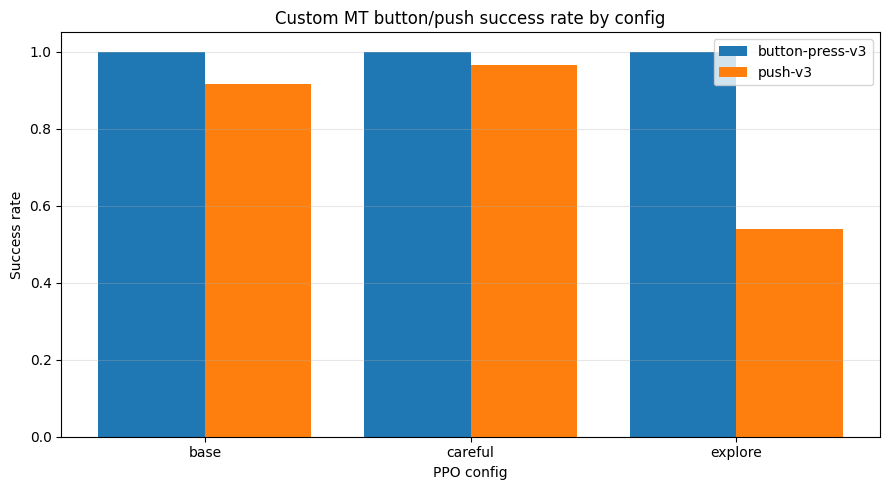

In [2]:
if custom_summary is None:
    print('No custom wrapper summary found. Run evaluate_button_push_custom_mt.py first.')
else:
    display(custom_summary)
    pivot = custom_summary.pivot_table(index='config', columns='task_name', values='success_rate')
    display(pivot)

    configs = list(pivot.index)
    tasks = list(pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(tasks), 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, pivot[task], width, label=task)
    ax.set_title('Custom MT button/push success rate by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Custom wrapper first-success step

Lower is better.

task_name,button-press-v3,push-v3
config,,
base,37.660,49.082969
careful,37.584,51.580913
explore,38.608,148.674074


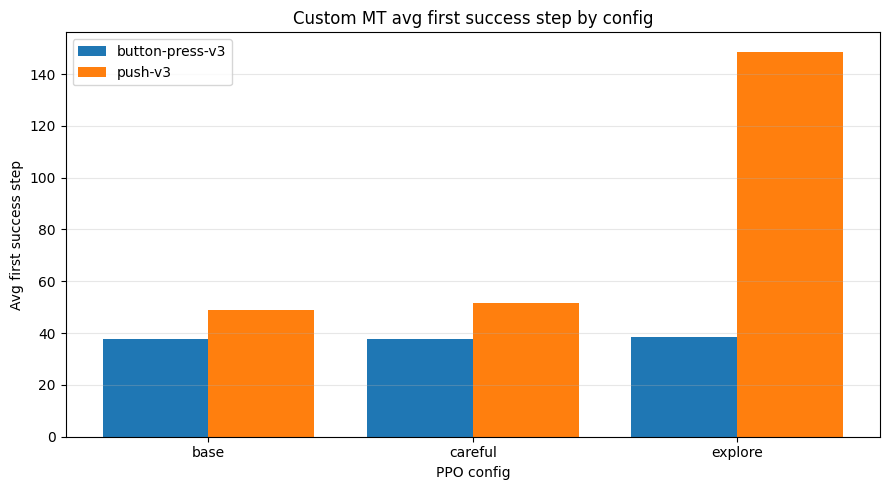

In [3]:
if custom_summary is None:
    print('No custom wrapper summary found.')
else:
    fs = custom_summary.pivot_table(index='config', columns='task_name', values='avg_first_success_step')
    display(fs)

    configs = list(fs.index)
    tasks = list(fs.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(tasks), 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, fs[task], width, label=task)
    ax.set_title('Custom MT avg first success step by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Avg first success step')
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Custom wrapper per-seed breakdown

Το raw CSV έχει rows ανά episode. Εδώ βλέπουμε αν κάποιο αποτέλεσμα εξαρτάται από συγκεκριμένο eval seed.

,config,task_idx,task_name,eval_seed,episode,success,return,episode_length,first_success_step
0,base,0,button-press-v3,1000,0,1.0,66.414363,38,38.0
1,base,0,button-press-v3,1000,1,1.0,68.248839,40,40.0
2,base,0,button-press-v3,1000,2,1.0,66.482193,38,38.0
3,base,0,button-press-v3,1000,3,1.0,67.079577,39,39.0
4,base,0,button-press-v3,1000,4,1.0,64.841262,36,36.0


,config,task_name,eval_seed,success_rate,avg_return,avg_first_success_step,episodes
0,base,button-press-v3,1000,1.00,63.989990,37.380000,50
1,base,push-v3,1000,0.96,197.061631,37.291667,50
2,careful,button-press-v3,1000,1.00,60.352332,37.480000,50
3,careful,push-v3,1000,1.00,129.102039,37.280000,50
4,explore,button-press-v3,1000,1.00,74.509168,37.800000,50
5,explore,push-v3,1000,0.58,981.722068,92.241379,50


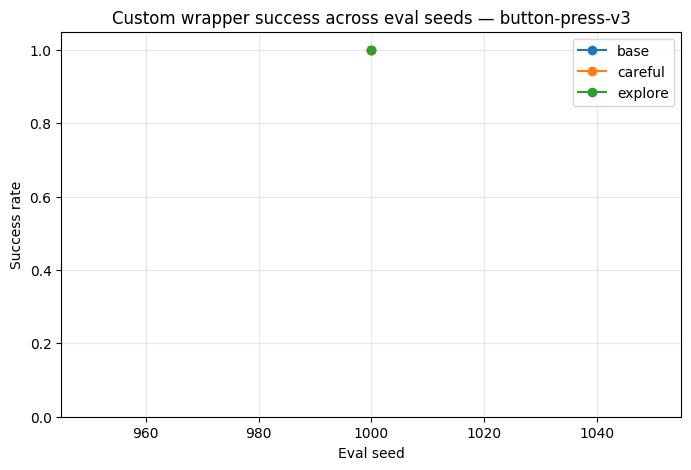

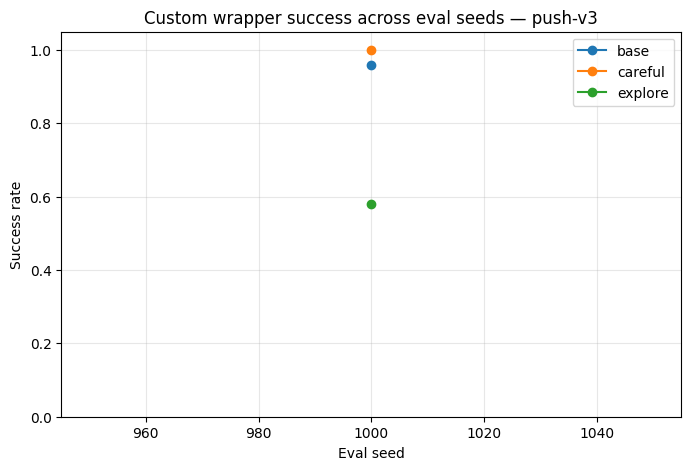

In [4]:
if custom_raw is None:
    print('No custom raw episodes found.')
else:
    display(custom_raw.head())
    by_seed = (
        custom_raw.groupby(['config', 'task_name', 'eval_seed'])
        .agg(
            success_rate=('success', 'mean'),
            avg_return=('return', 'mean'),
            avg_first_success_step=('first_success_step', 'mean'),
            episodes=('success', 'count'),
        )
        .reset_index()
    )
    display(by_seed)

    for task in sorted(by_seed['task_name'].unique()):
        d_task = by_seed[by_seed['task_name'] == task]
        fig, ax = plt.subplots(figsize=(8, 5))
        for config in sorted(d_task['config'].unique()):
            d = d_task[d_task['config'] == config].sort_values('eval_seed')
            ax.plot(d['eval_seed'], d['success_rate'], marker='o', label=config)
        ax.set_title(f'Custom wrapper success across eval seeds — {task}')
        ax.set_xlabel('Eval seed')
        ax.set_ylabel('Success rate')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

## Individual MT1 env evaluation

Αυτό το evaluation τεστάρει το custom MT policy πάνω στα κανονικά individual MT1 envs, με χειροκίνητο one-hot task ID.

,config,env_name,mean_success_rate,std_success_rate,mean_return,std_return_across_seeds,mean_steps,mean_first_success_step,eval_seeds,total_episodes
0,base,button-press-v3,1.000,0.000000,64.018024,0.848249,37.480,37.480000,5,750
1,base,push-v3,1.000,0.000000,130.673012,3.795481,38.032,38.032000,5,750
2,careful,button-press-v3,1.000,0.000000,59.394783,0.815485,37.512,37.512000,5,750
3,careful,push-v3,0.984,0.016733,187.583308,63.957441,44.908,37.514374,5,750


env_name,button-press-v3,push-v3
config,,
base,1.0,1.000
careful,1.0,0.984


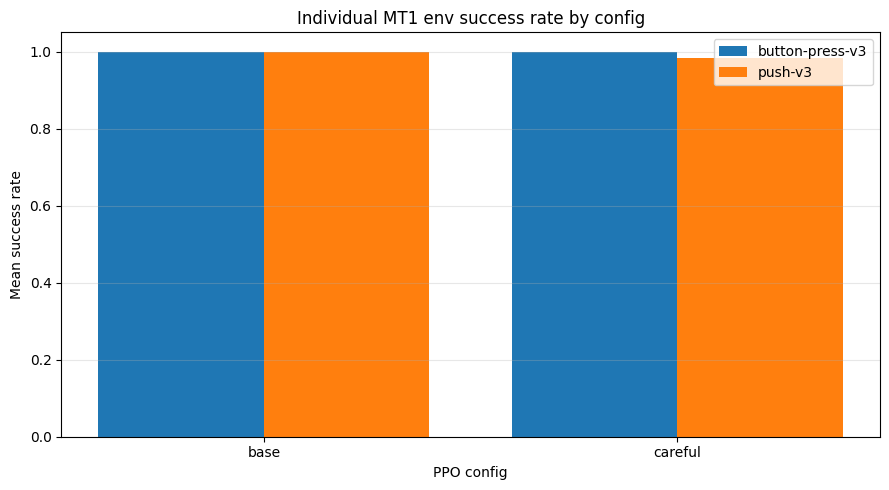

In [5]:
if indiv_final is None:
    print('No individual env final summary found. Run evaluate_custom_mt_button_push_individual.py first.')
else:
    display(indiv_final)
    pivot = indiv_final.pivot_table(index='config', columns='env_name', values='mean_success_rate')
    display(pivot)

    configs = list(pivot.index)
    envs = list(pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(envs), 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, env_name in enumerate(envs):
        ax.bar(x + (i - (len(envs)-1)/2) * width, pivot[env_name], width, label=env_name)
    ax.set_title('Individual MT1 env success rate by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Mean success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Compare custom-wrapper vs individual-env evaluation

Αν και τα δύο evaluations συμφωνούν, αυτό ενισχύει το συμπέρασμα ότι το policy όντως έμαθε τα tasks και όχι μόνο το custom wrapper.

,config,task,custom_wrapper_success,custom_wrapper_return,custom_wrapper_first_success,individual_env_success,individual_env_return,individual_env_first_success,success_diff_custom_minus_individual
0,base,button-press-v3,1.000,4377.957656,37.660000,1.000,64.018024,37.480000,0.000
1,base,push-v3,0.916,4229.004049,49.082969,1.000,130.673012,38.032000,-0.084
2,careful,button-press-v3,1.000,4348.215787,37.584000,1.000,59.394783,37.512000,0.000
3,careful,push-v3,0.964,4353.566266,51.580913,0.984,187.583308,37.514374,-0.020
4,explore,button-press-v3,1.000,4469.553665,38.608000,NaN,NaN,NaN,NaN
5,explore,push-v3,0.540,2042.106782,148.674074,NaN,NaN,NaN,NaN


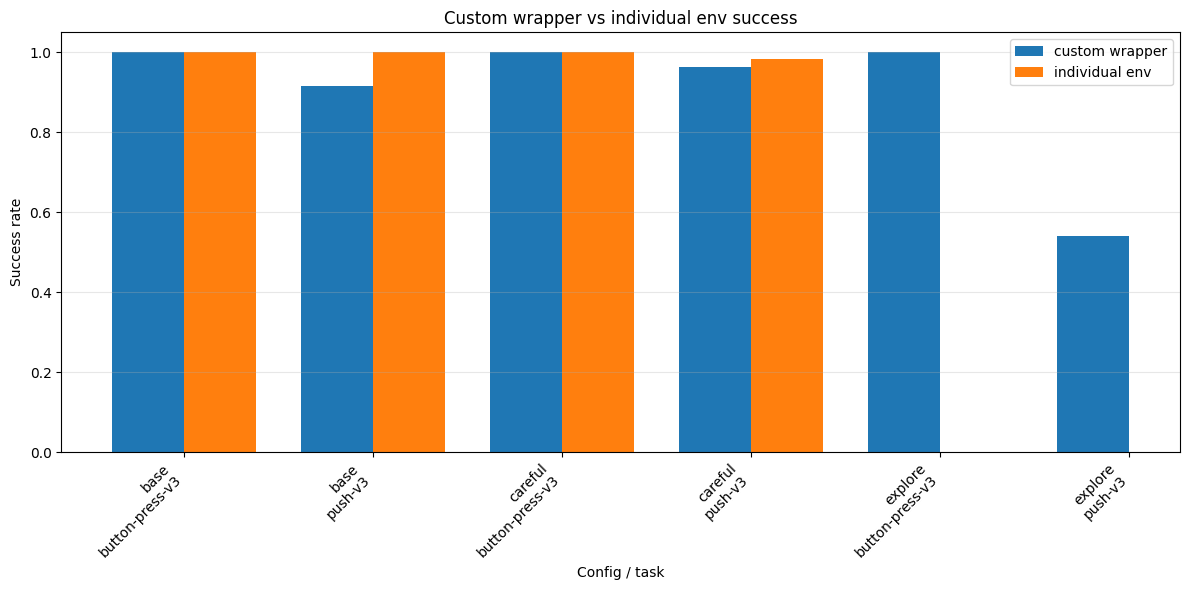

In [6]:
if custom_summary is None or indiv_final is None:
    print('Need both custom_summary and indiv_final to compare.')
else:
    cw = custom_summary.rename(columns={
        'config': 'config',
        'task_name': 'task',
        'success_rate': 'custom_wrapper_success',
        'avg_return': 'custom_wrapper_return',
        'avg_first_success_step': 'custom_wrapper_first_success',
    })[['config', 'task', 'custom_wrapper_success', 'custom_wrapper_return', 'custom_wrapper_first_success']]

    indiv = indiv_final.rename(columns={
        'env_name': 'task',
        'mean_success_rate': 'individual_env_success',
        'mean_return': 'individual_env_return',
        'mean_first_success_step': 'individual_env_first_success',
    })[['config', 'task', 'individual_env_success', 'individual_env_return', 'individual_env_first_success']]

    comparison = cw.merge(indiv, on=['config', 'task'], how='outer')
    comparison['success_diff_custom_minus_individual'] = comparison['custom_wrapper_success'] - comparison['individual_env_success']
    display(comparison)

    labels = comparison['config'] + '\n' + comparison['task']
    x = np.arange(len(comparison))
    width = 0.38

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, comparison['custom_wrapper_success'], width, label='custom wrapper')
    ax.bar(x + width/2, comparison['individual_env_success'], width, label='individual env')
    ax.set_title('Custom wrapper vs individual env success')
    ax.set_xlabel('Config / task')
    ax.set_ylabel('Success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Save figures

In [7]:
fig_dir = Path('button_push_custom_mt_figures')
fig_dir.mkdir(parents=True, exist_ok=True)
saved = []

if custom_summary is not None:
    pivot = custom_summary.pivot_table(index='config', columns='task_name', values='success_rate')
    configs = list(pivot.index)
    tasks = list(pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(tasks), 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, pivot[task], width, label=task)
    ax.set_title('Custom MT button/push success rate by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    out = fig_dir / 'custom_wrapper_success_by_config.png'
    fig.savefig(out, dpi=200, bbox_inches='tight')
    plt.close(fig)
    saved.append(out)

if indiv_final is not None:
    pivot = indiv_final.pivot_table(index='config', columns='env_name', values='mean_success_rate')
    configs = list(pivot.index)
    envs = list(pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(envs), 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, env_name in enumerate(envs):
        ax.bar(x + (i - (len(envs)-1)/2) * width, pivot[env_name], width, label=env_name)
    ax.set_title('Individual MT1 env success rate by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Mean success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    out = fig_dir / 'individual_env_success_by_config.png'
    fig.savefig(out, dpi=200, bbox_inches='tight')
    plt.close(fig)
    saved.append(out)

print('Saved figures:')
for p in saved:
    print(' -', p)

Saved figures:
 - button_push_custom_mt_figures\custom_wrapper_success_by_config.png
 - button_push_custom_mt_figures\individual_env_success_by_config.png
